#### PUNTO 1:

Las personas desocupadas se identifican como personas que no están ocupadas actualmente pero que buscan un empleo 
de manera activa. 

Fuente: https://www.indec.gob.ar/uploads/informesdeprensa/mercado_trabajo_eph_4trim24083C6B9E41.pdf Página 6.

PUNTO 2:

#### PUNTO 2:

Punto a)

Elegimos trabajar con los datos de Gran Buenos Aires.
En las siguientes celdas eliminamos los datos que no corresponden a la región elegida y unificamos ambas bases.

In [1]:
import pandas as pd

# Cargamos las bases
t2004 = pd.read_stata("D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/Individual_t104.dta")
t2024 = pd.read_excel("D:/Mis documentos/Estudio/Lic en economia/2do Año/Big data & machine learning/Tps/TP II/usu_individual_T124.xlsx")

# Convertimos los nombres de columnas a mayúsculas
t2004.columns = t2004.columns.str.upper()
t2024.columns = t2024.columns.str.upper()

# Añadimos columna de año
t2004['ANO_EPH'] = 2004
t2024['ANO_EPH'] = 2024

# Filtramos por región (Gran Buenos Aires en la base de datos del 2004 y "1" en la base del 2024)
t2004 = t2004[t2004['REGION'] == 'Gran Buenos Aires']
t2024 = t2024[t2024['REGION'] == 1]

# Columnas comunes
columnas_comunes = set(t2004.columns).intersection(t2024.columns)

# Recortamos a las columnas comunes
t2004_recortada = t2004[list(columnas_comunes)].copy()
t2024_recortada = t2024[list(columnas_comunes)].copy()

# Reafirmamos columna de año
t2004_recortada['ANO_EPH'] = 2004
t2024_recortada['ANO_EPH'] = 2024

# Eliminamos columnas completamente vacías
t2004_recortada = t2004_recortada.dropna(axis=1, how='all')
t2024_recortada = t2024_recortada.dropna(axis=1, how='all')

# Unificamos
df_unificada = pd.concat([t2004_recortada, t2024_recortada], ignore_index=True)

# Creamos copia filtrada por GBA (ya está filtrado, pero útil por claridad)
df_gba = df_unificada.copy()

Punto b)

La variables elegidas son las siguientes:
sexo, edad, estado_civil, cobertura_medica, sabe_leer_escribir,
asistencia_escolar, nivel_educativo, finalizo_nivel, condicion_actividad,
categoria_ocupacional, horas_ocupacion_principal, quiere_mas_horas,
busco_mas_horas, intensidad_ocupacional, ponderador

Renombramos las variables para facilitar la lectura y comprensión de los datos a trabajar.

Las que más valores faltantes tienen dentro de las 15 variables que elegimos son:
- horas_ocupacion_principal
- quiere_mas_horas
- busco_mas_horas
- intensidad_ocupacional
Todas con una cantidad de 3827 datos y correspondientes a la base del primer trimestre de 2024.

La base de datos correspondiente al primer trimestre del 2004 no contiende datos faltantes en las variables seleccionadas.

In [2]:
# Lista de variables seleccionadas
variables = [
    'CH04', 'CH06', 'CH07', 'CH08', 'CH09',
    'CH10', 'CH12', 'CH13', 'ESTADO', 'CAT_OCUP',
    'PP3E_TOT', 'PP03G', 'PP03I', 'INTENSI', 'PONDERA'
]

# Renombramiento de variables seleccionadas
renombrar_vars = {
    'CH04': 'sexo',
    'CH06': 'edad',
    'CH07': 'estado_civil',
    'CH08': 'cobertura_medica',
    'CH09': 'sabe_leer_escribir',
    'CH10': 'asistencia_escolar',
    'CH12': 'nivel_educativo',
    'CH13': 'finalizo_nivel',
    'ESTADO': 'condicion_actividad',
    'CAT_OCUP': 'categoria_ocupacional',
    'PP3E_TOT': 'horas_ocupacion_principal',
    'PP03G': 'quiere_mas_horas',
    'PP03I': 'busco_mas_horas',
    'INTENSI': 'intensidad_ocupacional',
    'PONDERA': 'ponderador'
}

# Llamamos a las variables que fueron renombradas
variables = [
    'sexo', 'edad', 'estado_civil', 'cobertura_medica', 'sabe_leer_escribir',
    'asistencia_escolar', 'nivel_educativo', 'finalizo_nivel', 'condicion_actividad',
    'categoria_ocupacional', 'horas_ocupacion_principal', 'quiere_mas_horas',
    'busco_mas_horas', 'intensidad_ocupacional', 'ponderador'
]

# Creamos una copia explícita del DataFrame filtrado antes de renombrar
df_gba = df_gba.copy()

# Renombramos columnas con seguridad
df_gba.rename(columns=renombrar_vars, inplace=True)

# Los dos pasos anteriores garantizan el buen funcionamiento de los Pandas.

# Creamos tablas de valores faltantes por año
faltantes_2004 = df_gba[df_gba['ANO_EPH'] == 2004][variables].isna().sum()
faltantes_2024 = df_gba[df_gba['ANO_EPH'] == 2024][variables].isna().sum()

# Mostramos los resultados como DataFrames ordenados
tabla_2004 = pd.DataFrame({'Variable': faltantes_2004.index, 'Faltantes_2004': faltantes_2004.values})
tabla_2024 = pd.DataFrame({'Variable': faltantes_2024.index, 'Faltantes_2024': faltantes_2024.values})

# Mostramos las tablas
print("# Tabla de faltantes - Año 2004:")
print(tabla_2004.sort_values(by='Faltantes_2004', ascending=False))

print("\n# Tabla de faltantes - Año 2024:")
print(tabla_2024.sort_values(by='Faltantes_2024', ascending=False))

# Tabla de faltantes - Año 2004:
                     Variable  Faltantes_2004
0                        sexo               0
1                        edad               0
2                estado_civil               0
3            cobertura_medica               0
4          sabe_leer_escribir               0
5          asistencia_escolar               0
6             nivel_educativo               0
7              finalizo_nivel               0
8         condicion_actividad               0
9       categoria_ocupacional               0
10  horas_ocupacion_principal               0
11           quiere_mas_horas               0
12            busco_mas_horas               0
13     intensidad_ocupacional               0
14                 ponderador               0

# Tabla de faltantes - Año 2024:
                     Variable  Faltantes_2024
10  horas_ocupacion_principal            3827
11           quiere_mas_horas            3827
12            busco_mas_horas            3827
13     intens

Punto c)

Cada una de las variables puede contener valores lógicos y otros que van en contra de la lógica, por ejemplo:
Si analizamos cuantas horas trabajó una persona en una semana los valores nunca pueden ser
menores a cero o mayores a 168 (que son las horas totales que contiene una semana).

Por ende, vamos a eliminar los valores que vayan en contra de la lógica de cada una de las variables que elegimos:
- edad: Eliminar si es negativa o mayor a 110
- horas_ocupacion_principal: Eliminar si es negativa o mayor a 168 (número de horas de una semana)
- nivel_educativo: Eliminar si no está entre 1 y 9 (Valores indicativos de la variable)
- categoria_ocupacional: Eliminar si no está entre 1 y 4 (Valores indicativos de la variable)
- intensidad_ocupacional: Eliminar si no está entre 1 y 4 (Valores indicativos de la variable)
- ponderador: Eliminar si es ≤ 0 
- condicion_actividad: Eliminar si no está entre 0 y 4 (Valores indicativos de la variable)
- sexo: Eliminar si no es 1 (varón) o 2 (mujer)
- estado_civil: Eliminar si no está entre 1 y 5 (Valores indicativos de la variable)
- cobertura_medica: Eliminar si valor no está en el conjunto observado válido de combinaciones
- sabe_leer_escribir: Eliminar si no es 1 (sí) o 2 (no)
- asistencia_escolar: Eliminar si no es 1, 2, 3 (Valores indicativos de la variable)
- finalizo_nivel: Eliminar si no es 1, 2 (Valores indicativos de la variable)
- quiere_mas_horas: Eliminar si no es 1 o 2 (Valores indicativos de la variable)
- busco_mas_horas: Eliminar si no es 1 o 2 (Valores indicativos de la variable)

In [3]:
# Convertimos las columnas relevantes a numéricas (si hay strings, se convierten a NaN)
columnas_a_convertir = [
    'edad',
    'horas_ocupacion_principal',
    'nivel_educativo',
    'categoria_ocupacional',
    'intensidad_ocupacional',
    'ponderador',
    'condicion_actividad',
    'sexo',
    'estado_civil',
    'cobertura_medica',
    'sabe_leer_escribir',
    'asistencia_escolar',
    'finalizo_nivel',
    'quiere_mas_horas',
    'busco_mas_horas'
]

for col in columnas_a_convertir:
    df_gba[col] = pd.to_numeric(df_gba[col], errors='coerce')

# Creamos una copia de trabajo limpia
df_limpio = df_gba.copy()

# Edad válida entre 0 y 110
df_limpio = df_limpio[(df_limpio['edad'] >= 0) & (df_limpio['edad'] <= 110)]

# Horas de trabajo válidas entre 0 y 168
df_limpio = df_limpio[(df_limpio['horas_ocupacion_principal'] >= 0) & 
                      (df_limpio['horas_ocupacion_principal'] <= 168)]

# Nivel educativo: entre 1 y 9
df_limpio = df_limpio[df_limpio['nivel_educativo'].between(1, 9)]

# Categoría ocupacional: 1 a 4
df_limpio = df_limpio[df_limpio['categoria_ocupacional'].between(1, 4)]

# Intensidad ocupacional: 1 a 4
df_limpio = df_limpio[df_limpio['intensidad_ocupacional'].between(1, 4)]

# Ponderador: > 0
df_limpio = df_limpio[df_limpio['ponderador'] > 0]

# Condición de actividad: 0 a 4
df_limpio = df_limpio[df_limpio['condicion_actividad'].between(0, 4)]

# Sexo: 1 (varón) o 2 (mujer)
df_limpio = df_limpio[df_limpio['sexo'].isin([1, 2])]

# Estado civil: 1 a 5
df_limpio = df_limpio[df_limpio['estado_civil'].between(1, 5)]

# Cobertura médica: conjunto válido según codificación oficial
valores_validos_cobertura = [1, 2, 3, 4, 9, 12, 13, 23, 123]
df_limpio = df_limpio[df_limpio['cobertura_medica'].isin(valores_validos_cobertura)]

# Saber leer y escribir: 1 o 2
df_limpio = df_limpio[df_limpio['sabe_leer_escribir'].isin([1, 2])]

# Asistencia escolar: 1, 2, 3
df_limpio = df_limpio[df_limpio['asistencia_escolar'].isin([1, 2, 3])]

# Finalizó nivel: 1 o 2
df_limpio = df_limpio[df_limpio['finalizo_nivel'].isin([1, 2])]

# Quiere más horas: 1 o 2
df_limpio = df_limpio[df_limpio['quiere_mas_horas'].isin([1, 2])]

# Buscó más horas: 1 o 2
df_limpio = df_limpio[df_limpio['busco_mas_horas'].isin([1, 2])]

#### PUNTO 3:

El gráfico presenta la composición porcentual de la población según sexo para los años 2004 y 2024, considerando únicamente los casos correspondientes a los Partidos del Gran Buenos Aires (AGLOMERADO 32), conforme a la codificación utilizada por la Encuesta Permanente de Hogares (EPH).

En el año 2004, la distribución por sexo muestra una ligera mayoría de mujeres, con un 52,4% frente al 47,6% de varones. En 2024 se mantiene esta tendencia, con un 53,1% de mujeres y un 46,9% de varones. Esta leve diferencia entre sexos resulta esperable y consistente con las tendencias demográficas observadas históricamente en la región.

Es importante aclarar que la base correspondiente a 2024 contiene una cantidad significativamente menor de observaciones respecto a la del año 2004 (1.422 casos frente a 5.811). No obstante, dado que el gráfico compara proporciones y no cantidades absolutas, la comparación sigue siendo válida en términos relativos.

En conclusión, no se observan cambios sustantivos en la composición por sexo de la población del Gran Buenos Aires entre ambos años. Las proporciones se mantienen relativamente estables, lo cual sugiere una estructura poblacional consistente en este aspecto.

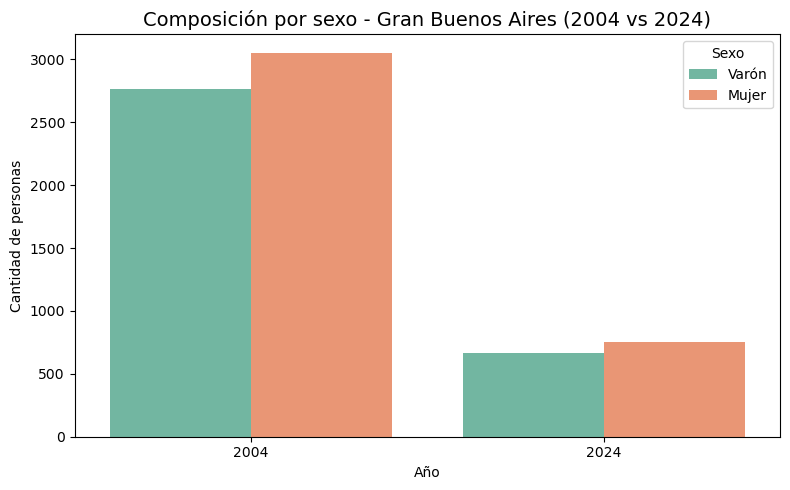

In [ ]:
# Filtro correcto de GBA en ambas bases
t2004 = t2004[t2004['AGLOMERADO'] == 'Partidos del GBA'].copy()
t2024 = t2024[t2024['AGLOMERADO'] == 32].copy()

# Crear variable sexo (ajuste en nombre de columna)
t2004['sexo'] = t2004['CH04'].map({'Varón': 'Varón', 'Mujer': 'Mujer'})
t2024['sexo'] = t2024['CH04'].map({1: 'Varón', 2: 'Mujer'})

# Año
t2004['año'] = 2004
t2024['año'] = 2024

# Unificación
personas = pd.concat([t2004[['sexo', 'año']], t2024[['sexo', 'año']]], ignore_index=True)
personas = personas.dropna(subset=['sexo'])

# Gráfico
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=personas, x='año', hue='sexo', palette='Set2')
plt.title('Composición por sexo - Gran Buenos Aires (2004 vs 2024)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad de personas')
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

In [ ]:
personas.groupby(['año', 'sexo']).size()

año   sexo 
2004  Mujer    3046
      Varón    2765
2024  Mujer     755
      Varón     667
dtype: int64

In [ ]:
personas['año'].value_counts()

año
2004    5811
2024    1422
Name: count, dtype: int64

Observación adicional sobre los tamaños muestrales:

Se observa que la cantidad total de personas relevadas en la base correspondiente al año 2024 (1.422 casos) es considerablemente menor en comparación con la base de 2004 (5.811 casos), lo cual se refleja en las alturas de las barras del gráfico. Esta diferencia no se debe a un error en el procesamiento, sino que fue verificada manualmente mediante el uso de value_counts() y groupby() sobre la variable año y la variable sexo.

#### PUNTO 4:

Análisis de la matriz de correlación – Gran Buenos Aires
La matriz de correlación permite examinar la relación lineal entre las variables seleccionadas en las bases del primer trimestre de 2004 y 2024 para la región del Gran Buenos Aires.
En ambos años, se observa una fuerte correlación positiva entre las variables estado y cat_inac, lo cual es esperable dado que ambas describen la condición de actividad de las personas. Esta asociación sugiere que quienes están desocupados o fuera del mercado laboral tienden a estar clasificados de manera consistente en ambas variables.
En cuanto a la relación entre el nivel educativo (nivel_ed / NIVEL_ED) y el estado laboral (estado), se evidencia una correlación negativa más pronunciada en 2024 respecto de 2004. Esto podría indicar que en 2024, el nivel educativo tiene un mayor impacto en la inserción laboral, posiblemente por una creciente demanda de cualificaciones en el mercado de trabajo.
Por otro lado, se destaca que en 2004, la variable ch06 (sexo) presenta correlaciones negativas moderadas con estado y cat_inac, reflejando diferencias de género más marcadas en la inserción laboral. En 2024, estas correlaciones se reducen, lo cual podría estar asociado a una evolución en la participación laboral de las mujeres.
Finalmente, el ingreso per cápita familiar (ipcf / IPCF) muestra baja correlación con las demás variables en ambos años, lo que sugiere que su variabilidad no se explica de forma lineal por las variables consideradas, y que posiblemente esté influenciado por factores adicionales como la composición del hogar o el tipo de empleo.

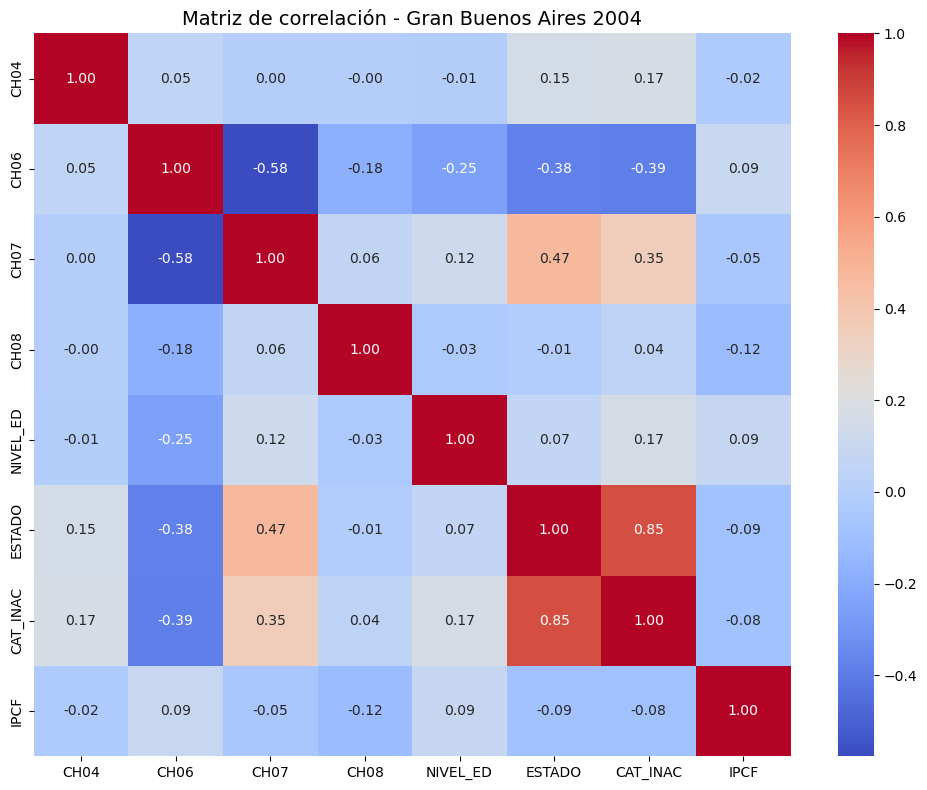

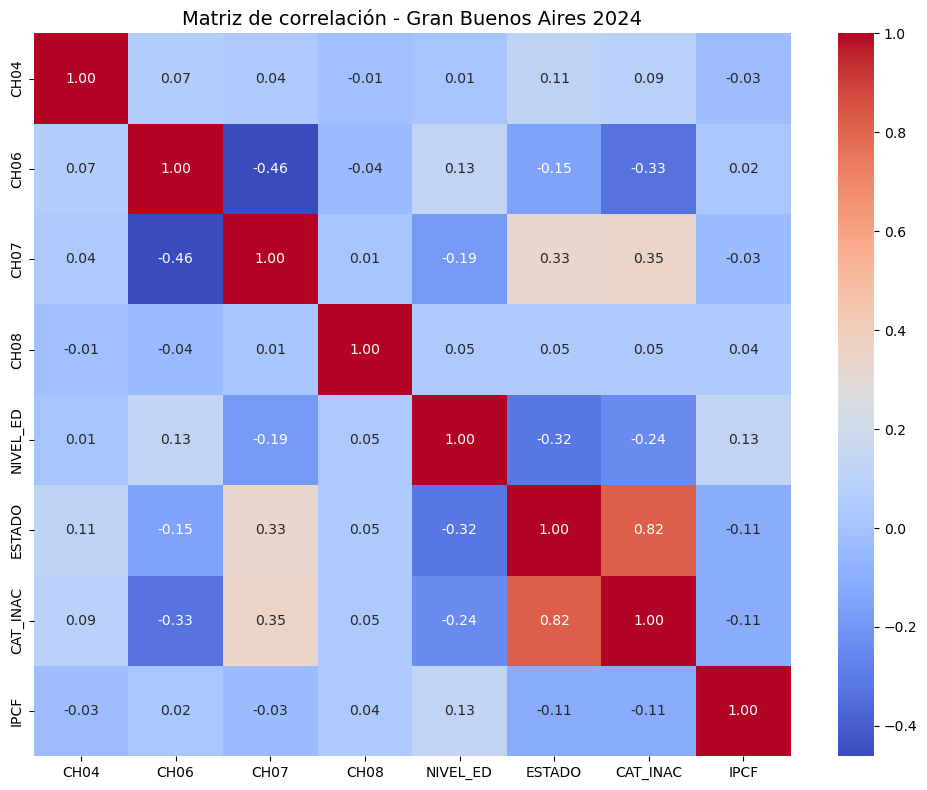

In [ ]:
# Filtrar bases por Gran Buenos Aires

# Para 2004: filtrar por nombre de aglomerado
t2004_gba = t2004[t2004['AGLOMERADO'] == 'Partidos del GBA'].copy()

# Para 2024: filtrar por código de aglomerado
t2024_gba = t2024[t2024['AGLOMERADO'] == 32].copy()

# Función para preparar el DataFrame numérico
def preparar_dataframe_numerico(df, columnas):
    df_corr = df[columnas].copy()

# Convertir columnas categóricas a códigos numéricos (si las hubiera)
    for col in df_corr.select_dtypes(include='category').columns:
        df_corr[col] = df_corr[col].cat.codes

# Eliminar filas con valores faltantes
    df_corr = df_corr.dropna()

# Devolver solo columnas numéricas limpias
    return df_corr.select_dtypes(include='number')

# Variables de interés (diferentes nombres por año)
vars_2004 = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF']
vars_2024 = ['CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF']

# Preparar datos 2004
df_corr_2004 = preparar_dataframe_numerico(t2004_gba, vars_2004)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr_2004.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación - Gran Buenos Aires 2004", fontsize=14)
plt.tight_layout()
plt.show()

# Preparar datos 2024
df_corr_2024 = preparar_dataframe_numerico(t2024_gba, vars_2024)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr_2024.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación - Gran Buenos Aires 2024", fontsize=14)
plt.tight_layout()
plt.show()

#### PUNTO 5:

En la muestra se puede distinguir un total de 311 desocupados y 2662 inactivos.

La media del ingreso per cápita según el estado del encuestado es la siguiente:
- Ocupados: 207644.84
- Desocupados: 85019.15
- Inactivos: 130704.60

In [8]:
# Copiamos el DataFrame filtrado por GBA y renombramos columnas
df_limpio = df_gba.copy()
df_limpio = df_limpio.rename(columns=renombrar_vars)

# Filtramos según la condición de actividad
ocupados = df_limpio[df_limpio['condicion_actividad'] == 1]
desocupados = df_limpio[df_limpio['condicion_actividad'] == 2]
inactivos = df_limpio[df_limpio['condicion_actividad'] == 3]

# Contamos cuántos hay de cada uno
n_desocupados = desocupados.shape[0]
n_inactivos = inactivos.shape[0]

print("# Cantidad de personas según condición de actividad:")
print(f"Desocupados: {n_desocupados}")
print(f"Inactivos: {n_inactivos}")

# Calculamos la media de IPCF para cada grupo
media_ipcf_ocupados = ocupados['IPCF'].mean()
media_ipcf_desocupados = desocupados['IPCF'].mean()
media_ipcf_inactivos = inactivos['IPCF'].mean()

print("\n# Media del ingreso per cápita familiar (IPCF) según condición de actividad:")
print(f"Ocupados: {media_ipcf_ocupados:.2f}")
print(f"Desocupados: {media_ipcf_desocupados:.2f}")
print(f"Inactivos: {media_ipcf_inactivos:.2f}")

# Cantidad de personas según condición de actividad:
Desocupados: 311
Inactivos: 2662

# Media del ingreso per cápita familiar (IPCF) según condición de actividad:
Ocupados: 207644.84
Desocupados: 85019.15
Inactivos: 130704.60


#### PUNTO 6:

Hay 41 personas que no reportaron sus ingresos en la EPH.

In [9]:
# Verificamos cuántas personas no respondieron su condición de actividad
cantidad_no_respondieron = df_limpio[df_limpio['condicion_actividad'] == 0].shape[0]
print(f"# Cantidad de personas que no respondieron su condición de actividad (ESTADO = 0): {cantidad_no_respondieron}")

# Creamos las dos bases separadas
respondieron = df_limpio[df_limpio['condicion_actividad'] != 0].copy()
norespondieron = df_limpio[df_limpio['condicion_actividad'] == 0].copy()

# Cantidad de personas que no respondieron su condición de actividad (ESTADO = 0): 41


#### PUNTO 7: 

En el gráfico podemos obersvar que la población economicamente activa en los periodos analizados no ha variado significativamente. Podemos afirmar que esta relación es fiable gracias al tamaño de la muestra (7647 en el caso del 2004 y 7051 en el de 2024).

In [ ]:
#================================
# Preparamos las bases de datos
#================================

# Normalizar el valor '1' como 'Gran Buenos Aires'
df_unificada['REGION'] = df_unificada['REGION'].replace({1: 'Gran Buenos Aires', '1': 'Gran Buenos Aires'})

# Filtrar para quedarse solo con Gran Buenos Aires
df_pea_gba = df_unificada[df_unificada['REGION'] == 'Gran Buenos Aires'].copy()

# Crear una nueva variable binaria: 1 si es PEA (estado 1 o 2), 0 si no
df_pea_gba['PEA'] = df_pea_gba['ESTADO'].apply(lambda x: 1 if x in ['Ocupado', 'Desocupado'] else 0)

# Reemplazar los valores binarios por etiquetas string homogéneas
df_pea_gba['PEA'] = df_pea_gba['PEA'].map({1: 'PEA', 0: 'No PEA'})

# Importamos Numpy:
import numpy as np

# Convertir la columna PEA a tipo object antes de asignar strings
df_pea_gba['PEA'] = df_pea_gba['PEA'].astype('object')

# actualizar la variable PEA en las filas del año 2024
df_pea_gba.loc[df_pea_gba['ANO_EPH'] == 2024, 'PEA'] = np.where(
    df_pea_gba.loc[df_pea_gba['ANO_EPH'] == 2024, 'ESTADO'].isin([1, 2]),
    'PEA',
    'No PEA'
)

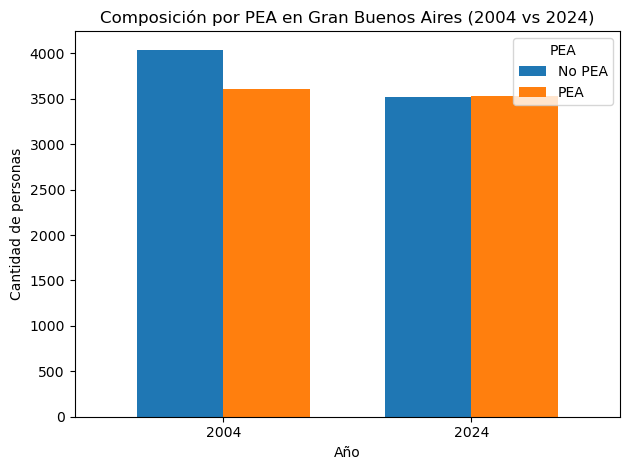

In [ ]:
#================================
# Generamos el gráfico
#================================

# Agrupar y contar
pea_counts = df_pea_gba.groupby(['ANO_EPH', 'PEA']).size().unstack()

# Crear gráfico de barras agrupadas
pea_counts.plot(kind='bar', width=0.7)

# Etiquetas y título
plt.xlabel('Año')
plt.ylabel('Cantidad de personas')
plt.title('Composición por PEA en Gran Buenos Aires (2004 vs 2024)')
plt.legend(title='PEA')

# Mostrar gráfico
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Analizamos la cantidad de datos que fueron extraídos de la muestra para la composición del gráfico
conteo_por_anio = df_pea_gba['ANO_EPH'].value_counts().sort_index()

print("# Cantidad de observaciones por año en df_pea_gba:")
print(conteo_por_anio)

# Cantidad de observaciones por año en df_pea_gba:
ANO_EPH
2004    7647
2024    7051
Name: count, dtype: int64


#### PUNTO 8:

En el primer gráfico podemos ver que no hay variaciones significativas en la PET entre los periodos analizados en el Gran Buenos Aires. Y, en el segundo gráfico, podemos viasualizar en términos relativos la distribución entre PET y PEA entre ambos periodos; Vemos que, al igual que el caso anterior, la composición de estas dos poblaciones se mantiene pareja para una muestra significativa de más de 3500 encuestados para cada población.

# Cantidad de personas por condición PET y año:
PET      No PET   PET
ANO_EPH              
2004       1754  5893
2024       1208  5843


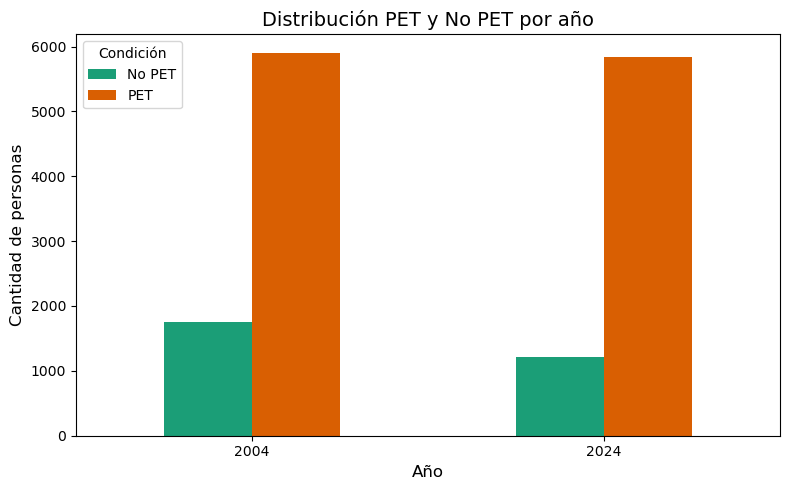

In [ ]:
# Convertimos 'CH06' a numérico (edad), ignorando errores
df_pea_gba['CH06'] = pd.to_numeric(df_pea_gba['CH06'], errors='coerce')

# Ahora sí podemos crear la columna PET
df_pea_gba['PET'] = df_pea_gba['CH06'] >= 14

# Recuento de personas por año y condición PET
pet_counts = df_pea_gba.groupby(['ANO_EPH', 'PET']).size().unstack()

# Reemplazamos 0 y 1 por etiquetas legibles (si todavía están como números)
pet_counts = pet_counts.rename(columns={1: 'PET', 0: 'No PET'})

# Mostramos la tabla
print("# Cantidad de personas por condición PET y año:")
print(pet_counts)

# Usamos el DataFrame pet_counts generado previamente

# Crear gráfico
pet_counts.plot(kind='bar', figsize=(8, 5), color=['#1b9e77', '#d95f02'])

# Etiquetas y título
plt.title('Distribución PET y No PET por año', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de personas', fontsize=12)
plt.legend(title='Condición')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Comparación entre PET y PEA por año:
          PET   PEA
ANO_EPH            
2004     5893  3607
2024     5843  3535


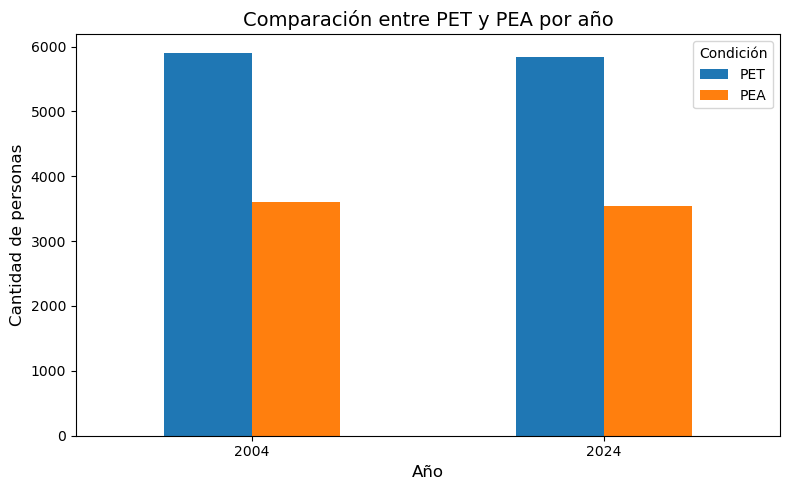

In [18]:
# Asignar PEA para todos los registros según ESTADO
df_pea_gba['PEA'] = df_pea_gba['ESTADO'].apply(
    lambda x: 'PEA' if str(x).strip().lower() in ['1', '2', 'ocupado', 'desocupado'] else 'No PEA'
)

# Contar personas por año y condición PEA
pea_counts = df_pea_gba.groupby(['ANO_EPH', 'PEA']).size().unstack()

# Seleccionamos solo los totales de PET y PEA por año
df_comparacion = pd.DataFrame({
    'PET': pet_counts['PET'],
    'PEA': pea_counts['PEA']
})

# Mostramos los datos para confirmar
print("# Comparación entre PET y PEA por año:")
print(df_comparacion)

# Graficamos
df_comparacion.plot(kind='bar', figsize=(8, 5), color=['#1f77b4', '#ff7f0e'])

# Etiquetas y formato
plt.title('Comparación entre PET y PEA por año', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de personas', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Condición')
plt.tight_layout()
plt.show()

#### PUNTO 9:

- Hay 409 personas desocupadas para la muestra del 2004 y 51 para la muestra del 2024.

In [ ]:
# Asignamos correctamente la variable de condición de actividad
t2004['condicion_actividad'] = t2004['ESTADO']
t2024['condicion_actividad'] = t2024['ESTADO']  # No P21

# Concatenamos solo las columnas necesarias
respondieron = pd.concat([
    t2004[['ANO_EPH', 'condicion_actividad']],
    t2024[['ANO_EPH', 'condicion_actividad']]
], ignore_index=True)

# Creamos variable 'desocupado': 1 si condición es 'Desocupado' o código 2
respondieron['desocupado'] = respondieron['condicion_actividad'].apply(
    lambda x: 1 if str(x).strip().lower() == 'desocupado' or x == 2 else 0
)

# Conteo de desocupados por año
conteo_desocupados = respondieron.groupby('ANO_EPH')['desocupado'].sum()

# Mostramos resultados
print("# Cantidad de personas desocupadas por año:")
print(conteo_desocupados)

Punto a)

La comparación entre 2004 y 2024 muestra diferencias notables en la proporción de desocupados según el nivel educativo. En 2024, los niveles con mayor proporción de desocupación corresponden a la educación secundaria incompleta y completa, así como también a quienes no alcanzaron a finalizar la primaria. En cambio, los niveles de educación superior presentan una menor proporción de desocupación, indicando una tendencia clara: a mayor nivel educativo, menor probabilidad de estar desocupado.

En 2004, la relación fue menos consistente. Se observa una proporción de desocupación significativa incluso en niveles más altos de instrucción, como la educación universitaria incompleta, lo cual sugiere que en ese período la formación académica no garantizaba necesariamente una mejor inserción laboral. En resumen, la comparación evidencia que en 2024 el mercado laboral premia más claramente los niveles educativos superiores, mientras que en 2004 la desocupación era más transversal.

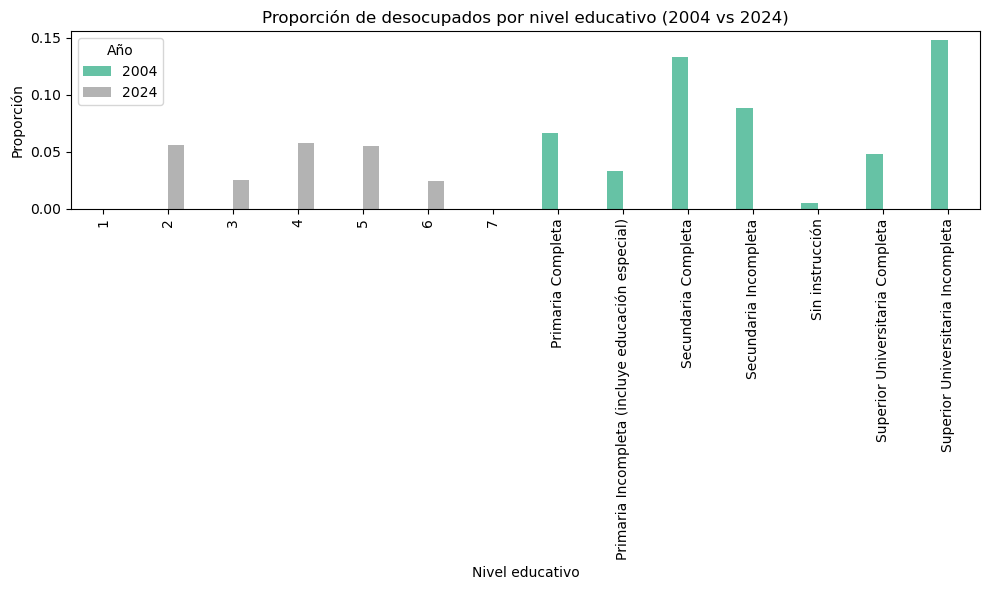

In [ ]:
# Creamos un DataFrame combinado con las columnas necesarias
niveles_educativos = pd.concat([
    t2004[['ANO_EPH', 'NIVEL_ED', 'ESTADO']],
    t2024[['ANO_EPH', 'NIVEL_ED', 'ESTADO']]
], ignore_index=True)

# Creamos variable desocupado como antes
niveles_educativos['desocupado'] = niveles_educativos['ESTADO'].apply(
    lambda x: 1 if str(x).strip().lower() == 'desocupado' or x == 2 else 0
)

# Agrupamos por año y nivel educativo: total y desocupados
tabla = niveles_educativos.groupby(['ANO_EPH', 'NIVEL_ED']).agg(
    total=('ESTADO', 'count'),
    desocupados=('desocupado', 'sum')
).reset_index()

# Calculamos proporción
tabla['proporcion'] = tabla['desocupados'] / tabla['total']

# Pivot para visualización
tabla_pivot = tabla.pivot(index='NIVEL_ED', columns='ANO_EPH', values='proporcion')

# Gráfico
tabla_pivot.plot(kind='bar', figsize=(10,6), colormap='Set2')
plt.title('Proporción de desocupados por nivel educativo (2004 vs 2024)')
plt.ylabel('Proporción')
plt.xlabel('Nivel educativo')
plt.legend(title='Año')
plt.tight_layout()
plt.show()

Punto b)

Análisis comparativo de la desocupación según grupo etario (2004 vs 2024)
A partir de la categorización de la variable de edad (CH06) en intervalos de 10 años, se observa que en 2004 la desocupación se concentra principalmente en los grupos de edad comprendidos entre 20 y 39 años, con una incidencia especialmente elevada en el segmento 20-29 años. A medida que avanza la edad, la proporción de personas desocupadas disminuye de forma progresiva, reflejando posiblemente una mayor estabilidad laboral entre los adultos mayores o una menor participación en el mercado de trabajo a edades avanzadas.

En contraste, para el año 2024 se registra una marcada reducción en la proporción de personas desocupadas en todos los grupos etarios. Esta diferencia puede explicarse por cambios en las condiciones del mercado laboral, políticas públicas de empleo, o bien por diferencias metodológicas en la medición y clasificación de la población económicamente activa (PEA) entre los dos períodos. La baja generalizada en 2024 también podría estar asociada a transformaciones en la estructura ocupacional, mayor inserción en sectores formales o un subregistro de situaciones de desocupación debido a nuevas dinámicas laborales.

En conjunto, el análisis evidencia una reducción sustancial de la desocupación entre 2004 y 2024, aunque se requieren estudios complementarios que evalúen los factores estructurales y contextuales que podrían haber influido en esta evolución.

C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_19104\623279303.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_unificada['edad'] = df_unificada['CH06'].apply(convertir_edad)
C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_19104\623279303.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_unificada['condicion_actividad'] = df_unificada['ESTADO']
C:\Users\Brian Emanuel Rios\AppData\Local\Temp\ipykernel_19104\623279303.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

Distribución por año y grupo de edad:
ANO_EPH  grupo_edad
2004     10-19         1306
         20-29         1247
         0-9           1230
         30-39          989
         40-49          900
         50-59          748
         60-69          572
         70-79          446
         80-89          189
         90-99           20
         nan              0
2024     10-19         1079
         20-29         1022
         40-49          958
         30-39          895
         50-59          844
         0-9            762
         60-69          683
         70-79          508
         80-89          202
         nan             51
         90-99           47
Name: count, dtype: int64


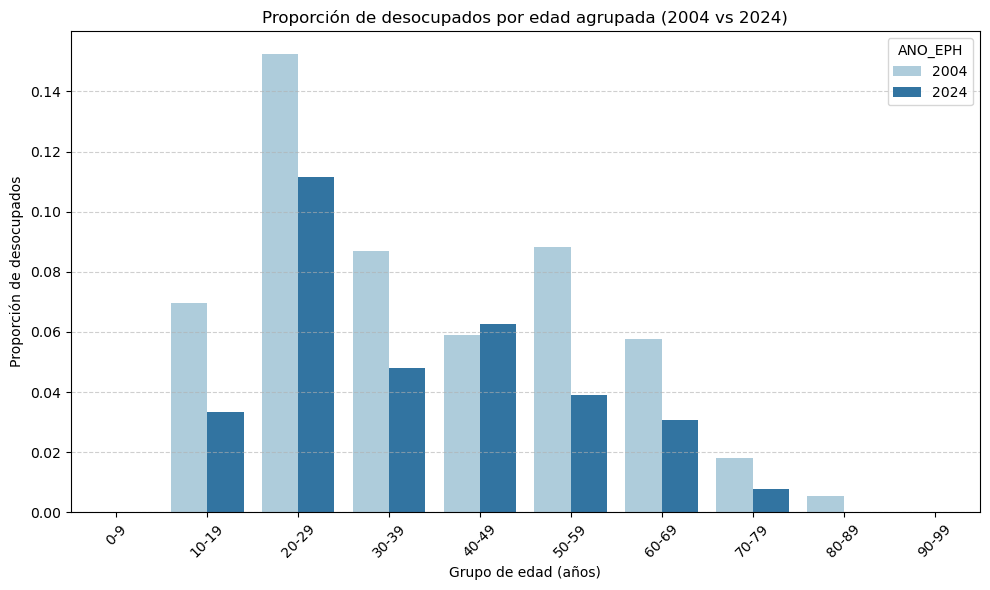

In [ ]:
# Convertimos edad
def convertir_edad(valor):
    if isinstance(valor, str):
        valor = valor.strip()
        if valor == 'Menos de 1 año':
            return 0
        if 'más años' in valor:
            return 98
        try:
            return int(float(valor))
        except:
            return None
    elif isinstance(valor, (int, float)):
        return int(valor)
    return None

# Aplicar función a columna CH06
df_unificada['edad'] = df_unificada['CH06'].apply(convertir_edad)

# Crear variable unificada 'condicion_actividad'
df_unificada['condicion_actividad'] = df_unificada['ESTADO']

# Crear variable binaria 'desocupado'
df_unificada['desocupado'] = df_unificada.apply(
    lambda row: 1 if (
        (row['ANO_EPH'] == 2004 and isinstance(row['condicion_actividad'], str) and row['condicion_actividad'].strip().lower() == 'desocupado') or
        (row['ANO_EPH'] == 2024 and row['condicion_actividad'] == 2)
    ) else 0,
    axis=1
)

# Agrupar edades en tramos de a 10 años
bins = list(range(0, 101, 10))
labels = [f"{i}-{i+9}" for i in bins[:-1]]
df_unificada['grupo_edad'] = pd.cut(df_unificada['edad'], bins=bins, labels=labels, right=False)

# Verificación rápida
print("Distribución por año y grupo de edad:")
print(df_unificada.groupby('ANO_EPH')['grupo_edad'].value_counts(dropna=False))

# Calcular proporción de desocupados por grupo de edad y año
df_grouped = df_unificada.groupby(['ANO_EPH', 'grupo_edad'], observed=True)['desocupado'].mean().reset_index()


plt.figure(figsize=(10,6))
sns.barplot(data=df_grouped, x='grupo_edad', y='desocupado', hue='ANO_EPH', palette='Paired')
plt.title("Proporción de desocupados por edad agrupada (2004 vs 2024)")
plt.xlabel("Grupo de edad (años)")
plt.ylabel("Proporción de desocupados")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Punto c)

El gráfico muestra una clara disminución en la proporción de desocupados con niveles educativos altos en 2024 respecto de 2004. En particular, los niveles de educación superior incompleta y completa presentan una menor representación entre los desocupados en 2024, lo que indica una mejora en la inserción laboral de personas con mayor formación. Por el contrario, se mantiene una alta proporción de desocupados con nivel secundario completo o incompleto en ambos años, aunque en 2024 esta proporción se distribuye de forma más equilibrada. Esto sugiere una consolidación de la relación entre nivel educativo y acceso al empleo, con mayor protección frente a la desocupación para quienes alcanzan niveles superiores.

Niveles educativos en desocupados 2004:
NIVEL_ED_LABEL
Secundaria Completa      137
Secundaria Incompleta    107
Primaria Completa        107
Superior Incompleto       95
Primaria Incompleta       43
Superior Completo         36
Sin instrucción            3
Name: count, dtype: int64

Niveles educativos en desocupados 2024:
NIVEL_ED_LABEL
Secundaria Incompleta    130
Secundaria Completa       61
Primaria Completa         55
Primaria Incompleta       35
Superior Incompleto       28
Sin instrucción            2
Name: count, dtype: int64


<Figure size 1200x600 with 0 Axes>

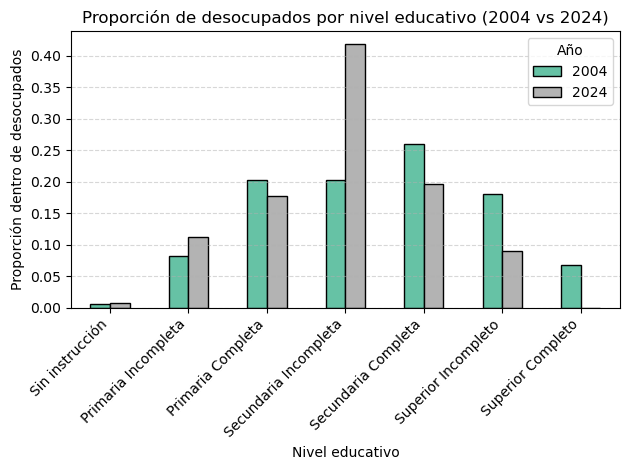

In [ ]:
# Filtramos solo personas desocupadas
df_desocupados = df_unificada[df_unificada['desocupado'] == 1].copy()

# Mapeamos etiquetas homogéneas de nivel educativo
etiquetas_nivel_ed = {
    1: "Sin instrucción",
    2: "Primaria Incompleta",
    3: "Primaria Completa",
    4: "Secundaria Incompleta",
    5: "Secundaria Completa",
    6: "Superior Incompleto",
    7: "Superior Completo",
    "Sin instrucción": "Sin instrucción",
    "Primaria Incompleta (incluye educación especial)": "Primaria Incompleta",
    "Primaria Completa": "Primaria Completa",
    "Secundaria Incompleta": "Secundaria Incompleta",
    "Secundaria Completa": "Secundaria Completa",
    "Superior Universitaria Incompleta": "Superior Incompleto",
    "Superior Universitaria Completa": "Superior Completo"
}

df_desocupados['NIVEL_ED_LABEL'] = df_desocupados['NIVEL_ED'].replace(etiquetas_nivel_ed)

# Recuento de valores únicos para control
print("Niveles educativos en desocupados 2004:")
print(df_desocupados[df_desocupados['ANO_EPH'] == 2004]['NIVEL_ED_LABEL'].value_counts())
print("\nNiveles educativos en desocupados 2024:")
print(df_desocupados[df_desocupados['ANO_EPH'] == 2024]['NIVEL_ED_LABEL'].value_counts())

# Tabla de proporciones por año y nivel educativo
tabla_nivel_ed = (
    df_desocupados
    .groupby(['ANO_EPH', 'NIVEL_ED_LABEL'], observed=True)
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .unstack()
)

# Aseguramos orden deseado
orden_etiquetas = [
    "Sin instrucción", "Primaria Incompleta", "Primaria Completa",
    "Secundaria Incompleta", "Secundaria Completa",
    "Superior Incompleto", "Superior Completo"
]
columnas_disponibles = [col for col in orden_etiquetas if col in tabla_nivel_ed.columns]
tabla_nivel_ed = tabla_nivel_ed[columnas_disponibles]

tabla_plot = tabla_nivel_ed.T.copy()
tabla_plot.columns.name = None

# Si las columnas son tuplas (MultiIndex), extraemos el primer elemento
if isinstance(tabla_plot.columns[0], tuple):
    tabla_plot.columns = [str(c[0]) for c in tabla_plot.columns]
else:
    tabla_plot.columns = [str(c) for c in tabla_plot.columns]

# Gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
tabla_plot.plot(kind='bar', colormap='Set2', edgecolor='black')
plt.title("Proporción de desocupados por nivel educativo (2004 vs 2024)")
plt.xlabel("Nivel educativo")
plt.ylabel("Proporción dentro de desocupados")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Año")
plt.tight_layout()
plt.show()